<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding Correlation**


Estimated time needed: **30** minutes


In this lab, you will work with a cleaned dataset to perform exploratory data analysis (EDA). You will examine the distribution of the data, identify outliers, and determine the correlation between different columns in the dataset.


## Objectives


In this lab, you will perform the following:


- Identify the distribution of compensation data in the dataset.

- Remove outliers to refine the dataset.

- Identify correlations between various features in the dataset.


## Hands on Lab


##### Step 1: Install and Import Required Libraries


In [1]:
# Install the necessary libraries
!pip install pandas
!pip install matplotlib
!pip install seaborn

# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 131.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 144.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 163.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 164.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 93.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 149.5 MB/s eta 0:00:00


### Step 2: Load the Dataset


In [2]:
# Load the dataset from the given URL
file_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"
df = pd.read_csv(file_url)

# Display the first few rows to understand the structure of the dataset
df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


<h3>Step 3: Analyze and Visualize Compensation Distribution</h3>


**Task**: Plot the distribution and histogram for `ConvertedCompYearly` to examine the spread of yearly compensation among respondents.


/tmp/ipykernel_1591/1276828767.py:15: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(comp_data, shade=True, color='orange')


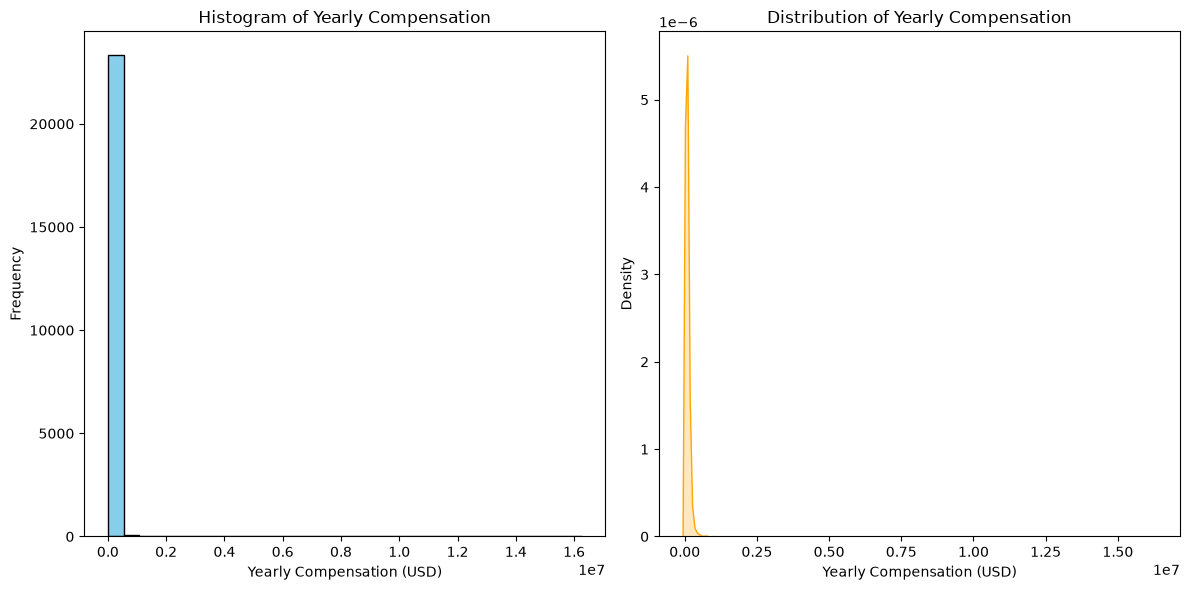

In [8]:

comp_data = df['ConvertedCompYearly'].dropna()
comp_data = comp_data[comp_data > 0]

plt.figure(figsize=(12, 6))

# Histogram
plt.subplot(1, 2, 1)
plt.hist(comp_data, bins=30, color='skyblue', edgecolor='black')
plt.title('Histogram of Yearly Compensation')
plt.xlabel('Yearly Compensation (USD)')
plt.ylabel('Frequency')

# Distribution plot
plt.subplot(1, 2, 2)
sns.kdeplot(comp_data, shade=True, color='orange')
plt.title('Distribution of Yearly Compensation')
plt.xlabel('Yearly Compensation (USD)')

plt.tight_layout()
plt.show()

<h3>Step 4: Calculate Median Compensation for Full-Time Employees</h3>


**Task**: Filter the data to calculate the median compensation for respondents whose employment status is "Employed, full-time."


In [52]:
mediann= df['ConvertedCompYearly'].median()
mediann

np.float64(65000.0)

In [27]:
# Display all unique country names containing 'Iran'
iran_names = df['Country'][df['Country'].str.contains('Iran', na=False)]
print(iran_names.unique())

<StringArray>
['Iran, Islamic Republic of...']
Length: 1, dtype: str


In [7]:
#filter full-time employees
fulltime_emp= df[df['Employment']== 'Employed, full-time']

comp_fulltime= fulltime_emp['ConvertedCompYearly'].dropna() 
comp_fulltime= comp_fulltime[comp_fulltime >0] 

comp_fulltime_median= comp_fulltime.median() 

print (f"Median compensation for full-time employees is: ${comp_fulltime_median}")

Median compensation for full-time employees is: $69814.0


<h3>Step 5: Analyzing Compensation Range and Distribution by Country</h3>


Explore the range of compensation in the ConvertedCompYearly column by analyzing differences across countries. Use box plots to compare the compensation distributions for each country to identify variations and anomalies within each region, providing insights into global compensation trends.



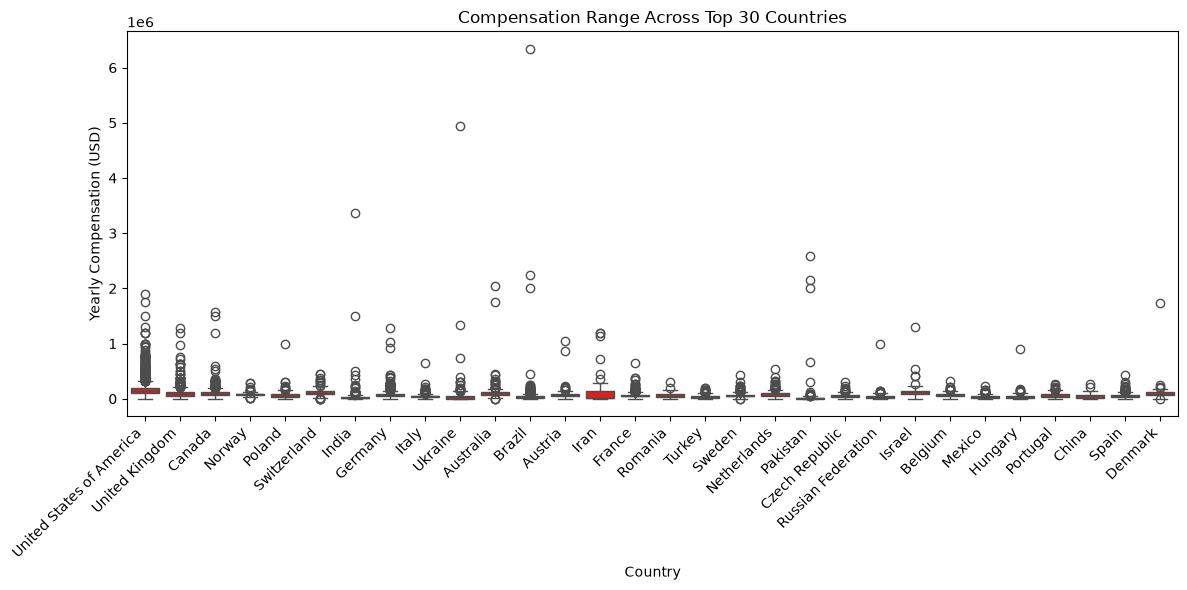

In [29]:

df['Country']= df['Country'].replace('United Kingdom of Great Britain and Northern Ireland', 'United Kingdom') 
df['Country']= df['Country'].replace('Iran, Islamic Republic of...', 'Iran') 

# Shorten countries to top 20 only
top_countries= df['Country'].value_counts().nlargest(30).index 
df_top= df [df['Country'].isin(top_countries)] 

#box plot 
plt.figure(figsize=(12,6)) 
sns.boxplot(x= 'Country', y= 'ConvertedCompYearly', data= df_top, color= 'red')
plt.title("Compensation Range Across Top 30 Countries") 
plt.xticks(rotation=45, ha='right') 
plt.ylabel("Yearly Compensation (USD)") 
plt.xlabel("Country") 
plt.tight_layout() 
plt.show()



<h3>Step 6: Removing Outliers from the Dataset</h3>


**Task**: Create a new DataFrame by removing outliers from the `ConvertedCompYearly` column to get a refined dataset for correlation analysis.


In [33]:
## Write your code here
#find q3 and q1
Q1= df['ConvertedCompYearly'].quantile(0.25)
Q3= df['ConvertedCompYearly'].quantile(0.75)

#Interquartile Range 
IQR= Q3-Q1 

#define bounds to filter outliers
lower_bound= Q1 - 1.5 * IQR
upper_bound= Q3 + 1.5 * IQR 

#filter dataframe to remove outliers 
df_no_outliers= df[
(df['ConvertedCompYearly'] >= lower_bound) &
(df['ConvertedCompYearly']<= upper_bound)]

print (f"Original dataset size: {df.shape[0]}") 
print (f"Dataset after removing outliers: {df_no_outliers.shape[0]}")

Original dataset size: 65437
Dataset after removing outliers: 22457


<h3>Step 7: Finding Correlations Between Key Variables</h3>


**Task**: Calculate correlations between `ConvertedCompYearly`, `WorkExp`, and `JobSatPoints_1`. Visualize these correlations with a heatmap.


                     ConvertedCompYearly   WorkExp  JobSatPoints_1
ConvertedCompYearly             1.000000  0.154114        0.020306
WorkExp                         0.154114  1.000000       -0.026490
JobSatPoints_1                  0.020306 -0.026490        1.000000


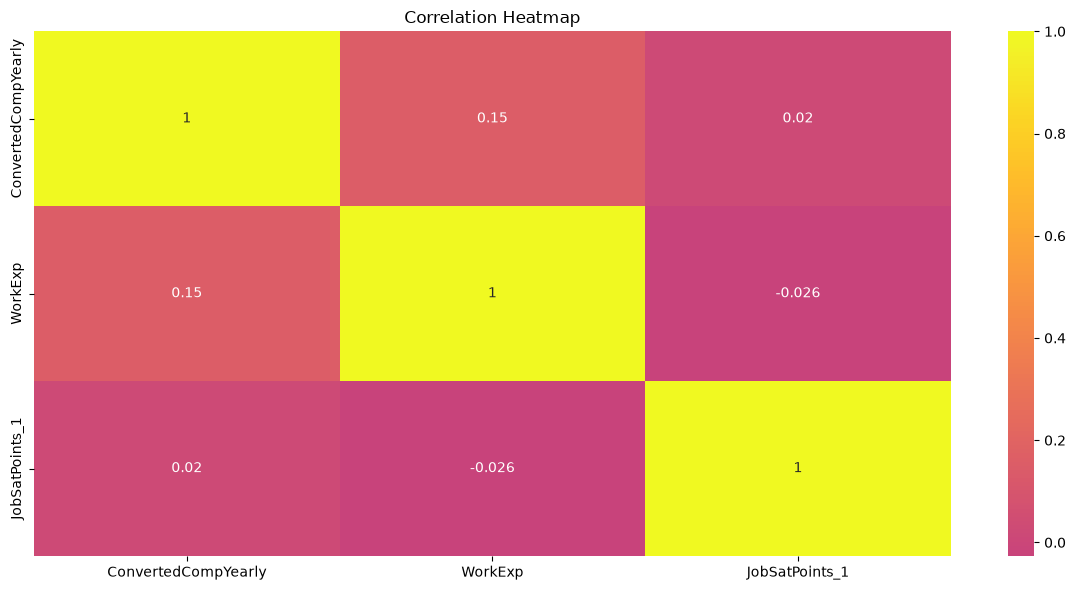

In [45]:
import pandas as pd
import seaborn as sns

#assign columns to variable 
corr_cols= [ 
    'ConvertedCompYearly', 'WorkExp', 'JobSatPoints_1']

#pearson correlation 
corr_matrix = df[corr_cols].corr(method='pearson')

print (corr_matrix) 

#visualize with heatmap 
plt.figure(figsize=(12,6)) 
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap= 'plasma', 
    center=0) 
plt.title("Correlation Heatmap") 
plt.tight_layout() 
plt.show() 

<h3>Step 8: Scatter Plot for Correlations</h3>


**Task**: Create scatter plots to examine specific correlations between `ConvertedCompYearly` and `WorkExp`, as well as between `ConvertedCompYearly` and `JobSatPoints_1`.


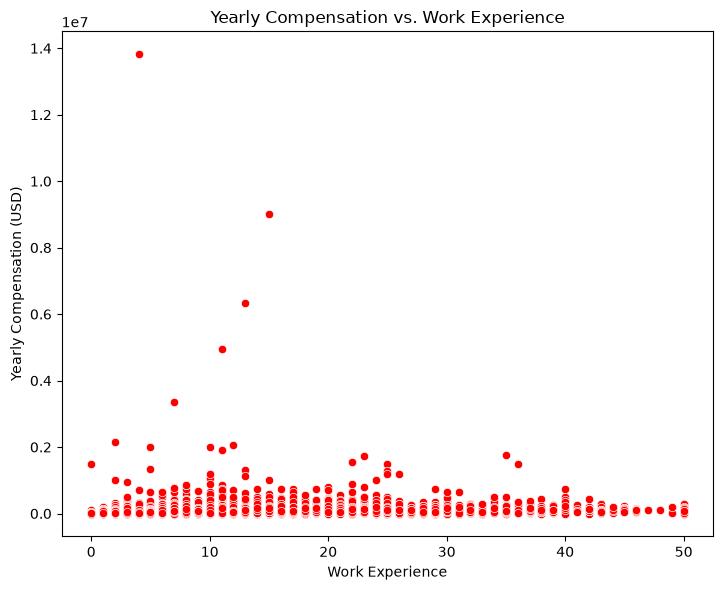

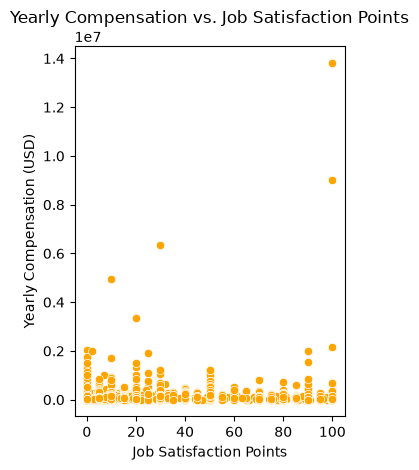

In [50]:
## Write your code here
plt.figure(figsize=(14,6))

#ConvertedCompYearl vs WorkExp Scatterplot 
plt.subplot (1,2,1) 
sns.scatterplot(x='WorkExp', y= 'ConvertedCompYearly', data=df, color= 'red') 
plt.title("Yearly Compensation vs. Work Experience") 
plt.ylabel("Yearly Compensation (USD)") 
plt.xlabel("Work Experience") 

plt.tight_layout() 
plt.show()  

#ConvertedCompYearl vs Jobsatpoints_1
plt.subplot (1,2,2) 
sns.scatterplot(x='JobSatPoints_1', y= 'ConvertedCompYearly', data=df, color= 'orange') 
plt.title("Yearly Compensation vs. Job Satisfaction Points") 
plt.ylabel("Yearly Compensation (USD)") 
plt.xlabel("Job Satisfaction Points") 

plt.tight_layout() 
plt.show() 

In this lab, you practiced essential skills in correlation analysis by:

- Examining the distribution of yearly compensation with histograms and box plots.
- Detecting and removing outliers from compensation data.
- Calculating correlations between key variables such as compensation, work experience, and job satisfaction.
- Visualizing relationships with scatter plots and heatmaps to gain insights into the associations between these features.

By following these steps, you have developed a solid foundation for analyzing relationships within the dataset.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
